# Part 1 — Baseline Toxicity Classifier




In [1]:
!pip install -U transformers accelerate datasets scikit-learn matplotlib seaborn

  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-1.11.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
Using cached transformers-5.5.4-py3-none-any.whl (10.2 MB)
Using cached huggingface_hub-1.11.0-py3-none-any.whl (645 kB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 0.36.2

    Uninstalling huggingface_hub-0.36.2:

   ---------------------------------------- 0/4 [huggingface-hub]
      Successfully uninstalled huggingface_hub-0.36.2
   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   --------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip uninstall -y transformers
!pip install transformers==4.40.0 accelerate==0.28.0

Found existing installation: transformers 5.5.4
Uninstalling transformers-5.5.4:
  Successfully uninstalled transformers-5.5.4
  Using cached transformers-4.40.0-py3-none-any.whl.metadata (137 kB)
  Using cached accelerate-0.28.0-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1-cp311-none-win_amd64.whl.metadata (6.9 kB)
Using cached transformers-4.40.0-py3-none-any.whl (9.0 MB)
Using cached accelerate-0.28.0-py3-none-any.whl (290 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.19.1-cp311-none-win_amd64.whl (2.2 MB)

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 1.11.0

    Uninstalling huggingface_hub-1.11.0:

      Successfully uninstalled huggingface_hub-1.11.0

   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   --------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0420 03:16:16.177000 1132 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


## Configuration

Edit these settings depending on whether you want a **fast CPU test run** or a **final run**.


In [4]:
# =========================
# CONFIG
# =========================

DATA_PATH = r"C:\Users\maaaa\Desktop\RAI_assignment2\jigsaw-unintended-bias-train.csv"

# Fast CPU mode (recommended for your laptop first)
FAST_MODE = True

if FAST_MODE:
    TRAIN_SIZE = 20000      # fast local run
    EVAL_SIZE = 5000
    NUM_EPOCHS = 2
    MAX_LENGTH = 96
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16
else:
    # Final assignment settings
    TRAIN_SIZE = 100000
    EVAL_SIZE = 20000
    NUM_EPOCHS = 3
    MAX_LENGTH = 128
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 16

MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = "./models_cpu_part1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print({
    "FAST_MODE": FAST_MODE,
    "TRAIN_SIZE": TRAIN_SIZE,
    "EVAL_SIZE": EVAL_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "MAX_LENGTH": MAX_LENGTH
})


{'FAST_MODE': True, 'TRAIN_SIZE': 20000, 'EVAL_SIZE': 5000, 'NUM_EPOCHS': 2, 'MAX_LENGTH': 96}


In [5]:
df = pd.read_csv(DATA_PATH)
df = df[["comment_text", "toxic"]].dropna()
df["label"] = (df["toxic"] >= 0.5).astype(int)
df = df[["comment_text", "label"]]

print("Full dataset shape:", df.shape)
print(df["label"].value_counts(normalize=True))
df.head()


Full dataset shape: (1902191, 2)
label
0    0.920034
1    0.079966
Name: proportion, dtype: float64


,comment_text,label
0,"This is so cool. It's like, 'would you want yo...",0
1,Thank you!! This would make my life a lot less...,0
2,This is such an urgent design problem; kudos t...,0
3,Is this something I'll be able to install on m...,0
4,haha you guys are a bunch of losers.,1


## Stratified split and sampling

This keeps the toxic/non-toxic balance roughly consistent.


In [6]:
# First create a held-out eval split from the full dataset
train_pool_df, eval_df = train_test_split(
    df,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=SEED
)

# Then take a stratified train subset from the remaining pool
train_df, _ = train_test_split(
    train_pool_df,
    train_size=TRAIN_SIZE,
    stratify=train_pool_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Eval size:", len(eval_df))
print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))
print("\nEval label distribution:")
print(eval_df["label"].value_counts(normalize=True))


Train size: 20000
Eval size: 5000

Train label distribution:
label
0    0.92005
1    0.07995
Name: proportion, dtype: float64

Eval label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["comment_text"])
eval_dataset = eval_dataset.remove_columns(["comment_text"])

train_dataset.set_format(type="torch")
eval_dataset.set_format(type="torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_dataset)
print(eval_dataset)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 5000/5000 [00:00<00:00, 6253.57 examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 20000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 5000
})


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Metrics

The trainer reports metrics at threshold 0.5 during training.  
Later we will test thresholds 0.3, 0.4, 0.5, 0.6, 0.7 as required.


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs)
    }


## Training

Notes for CPU:
- `fp16=False` is required.
- `report_to="none"` disables MLflow/W&B issues.
- `save_strategy="epoch"` keeps one checkpoint.


In [10]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()


  0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  2%|▏         | 100/5000 [05:53<5:33:10,  4.08s/it]

{'loss': 0.3262, 'grad_norm': 0.5303571224212646, 'learning_rate': 1.9600000000000002e-05, 'epoch': 0.04}


  4%|▍         | 200/5000 [12:08<5:44:04,  4.30s/it]

{'loss': 0.2905, 'grad_norm': 0.4858874976634979, 'learning_rate': 1.9200000000000003e-05, 'epoch': 0.08}


  6%|▌         | 300/5000 [18:25<4:10:15,  3.19s/it]

...

                                                     
100%|██████████| 5000/5000 [4:27:42<00:00,  2.85s/it]

{'eval_loss': 0.23963002860546112, 'eval_accuracy': 0.9422, 'eval_f1_macro': 0.7834569826431406, 'eval_auc_roc': 0.9206489130434782, 'eval_runtime': 395.7001, 'eval_samples_per_second': 12.636, 'eval_steps_per_second': 0.791, 'epoch': 2.0}


100%|██████████| 5000/5000 [4:27:48<00:00,  3.21s/it]

{'train_runtime': 16068.5997, 'train_samples_per_second': 2.489, 'train_steps_per_second': 0.311, 'train_loss': 0.17348553886413573, 'epoch': 2.0}


TrainOutput(global_step=5000, training_loss=0.17348553886413573, metrics={'train_runtime': 16068.5997, 'train_samples_per_second': 2.489, 'train_steps_per_second': 0.311, 'total_flos': 972861273760704.0, 'train_loss': 0.17348553886413573, 'epoch': 2.0})

In [11]:
pred_output = trainer.predict(eval_dataset)
logits = pred_output.predictions
labels = pred_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

print("Prediction shape:", logits.shape)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 313/313 [06:25<00:00,  1.23s/it]

Prediction shape: (5000, 2)


## Threshold sweep (required)


In [12]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    row = {
        "threshold": t,
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs)
    }
    threshold_results.append(row)

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,accuracy,f1_macro,auc_roc
0,0.3,0.9410,0.786076,0.920649
1,0.4,0.9418,0.785800,0.920649
2,0.5,0.9422,0.783457,0.920649
3,0.6,0.9424,0.781113,0.920649
4,0.7,0.9438,0.783893,0.920649


In [13]:
best_threshold = threshold_df.sort_values("f1_macro", ascending=False).iloc[0]["threshold"]
best_threshold


0.3

In [14]:
preds = (probs >= best_threshold).astype(int)

acc = accuracy_score(labels, preds)
f1m = f1_score(labels, preds, average="macro")
auc = roc_auc_score(labels, probs)
cm = confusion_matrix(labels, preds)

print(f"Chosen threshold: {best_threshold}")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (macro): {f1m:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print("Confusion Matrix:")
print(cm)


Chosen threshold: 0.3
Accuracy: 0.9410
F1 (macro): 0.7861
AUC-ROC: 0.9206
Confusion Matrix:
[[4480  120]
 [ 175  225]]


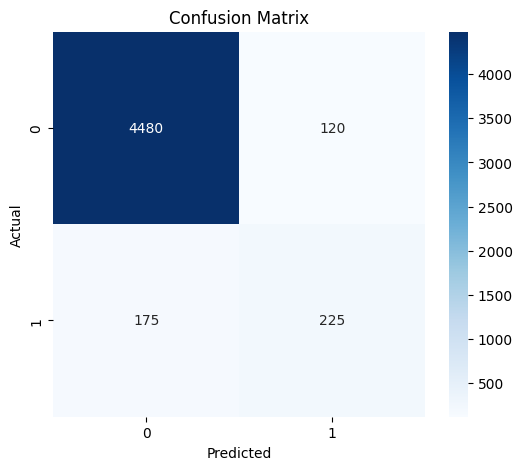

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


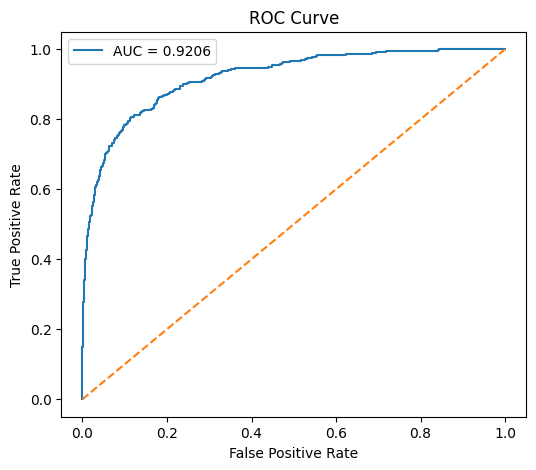

In [16]:
fpr, tpr, _ = roc_curve(labels, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


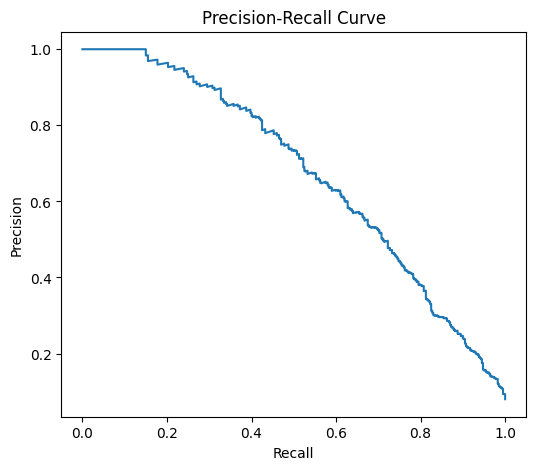

In [17]:
precision, recall, _ = precision_recall_curve(labels, probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


## Save model


In [18]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved to:", OUTPUT_DIR)


Saved to: ./models_cpu_part1


## Markdown answer for your notebook

You can paste/adapt this in a markdown cell:

**Threshold Justification**

I selected the threshold that produced the highest macro-F1 on the evaluation subset. A lower threshold catches more toxic content but also increases false positives, while a higher threshold reduces false positives but risks missing genuinely toxic comments. For a moderation system, this threshold reflects a trade-off between user safety and over-enforcement. In my setup, the chosen threshold provided the best balance between these priorities on the held-out evaluation data.

## CPU advice
- First run with `FAST_MODE = True`.
- For final submission, switch to `FAST_MODE = False`.
- If CPU is still too slow, keep `TRAIN_BATCH_SIZE = 8` and leave `MAX_LENGTH = 96` for local testing.
